In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df= pd.read_csv("/content/height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [3]:
df.isnull().sum()

,0
Weight,0
Height,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 496.0 bytes


In [5]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


In [8]:
np.percentile(df["Weight"],[25,75])

array([59., 86.])

In [9]:
np.percentile(df["Height"],[25,75])

array([142.5, 175. ])

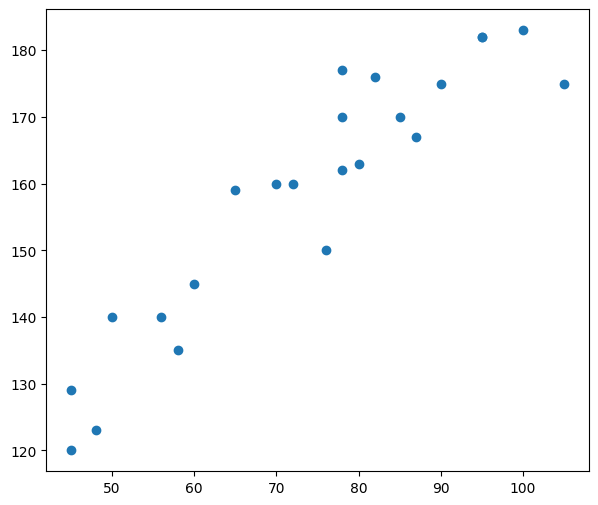

In [17]:
plt.figure(figsize=(7,6))
plt.scatter(df['Weight'],df['Height'])
plt.show()

<Axes: >

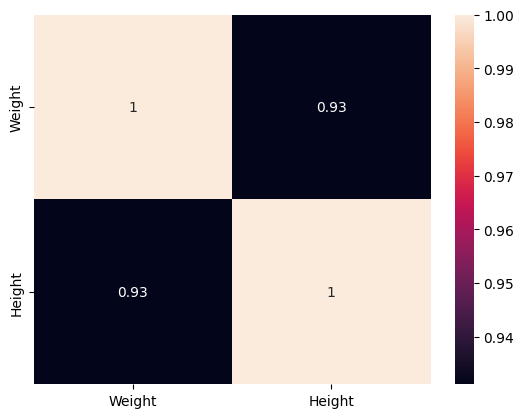

In [18]:
sns.heatmap(df.corr(),annot=True)

<Axes: ylabel='Count'>

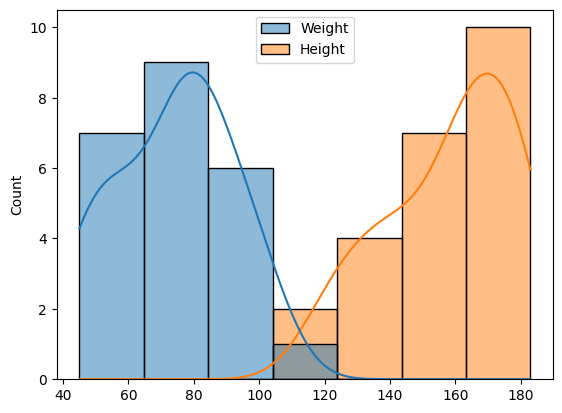

In [20]:
sns.histplot(df,kde=True)

<Axes: ylabel='Weight'>

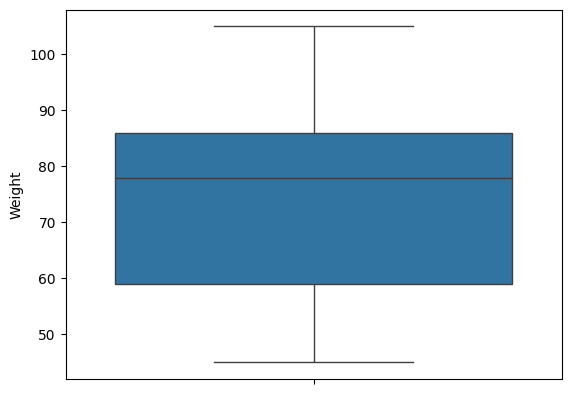

In [21]:
sns.boxplot(df["Weight"])

<Axes: ylabel='Height'>

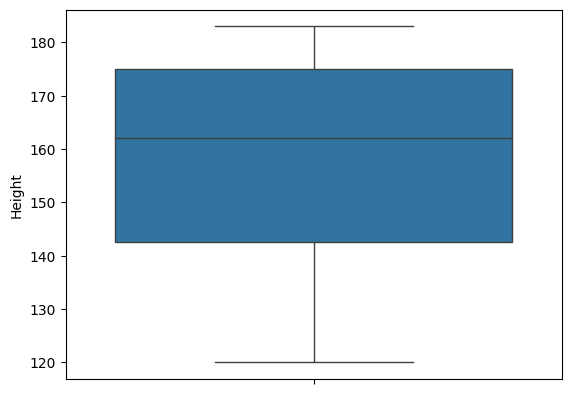

In [22]:
sns.boxplot(df["Height"])

In [23]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import  train_test_split

X_train,X_test,y_train,y_test=train_test_split(df[["Weight"]],df["Height"], test_size=0.30,random_state=7)
print(X_train.shape)
print(y_train.shape)

(16, 1)
(16,)


In [52]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print(X_train.std())
print(X_test.std())

0.9999999999999999
1.3732573984686651


In [53]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)

y_pred= model.predict(X_test)


## Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Coefficient or slope:",model.coef_)
print("Intercept:",model.intercept_)
print(f"MAE: {mean_absolute_error(y_test,y_pred)}")
print(f"MSE: {mean_squared_error(y_test,y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test,y_pred))}")
print(f"R2: {r2_score(y_test,y_pred)}")

Coefficient or slope: [15.93260176]
Intercept: 161.0625
MAE: 5.997234375036494
MSE: 70.10525397486418
RMSE: 8.372888030713428
R2: 0.8490704110382976


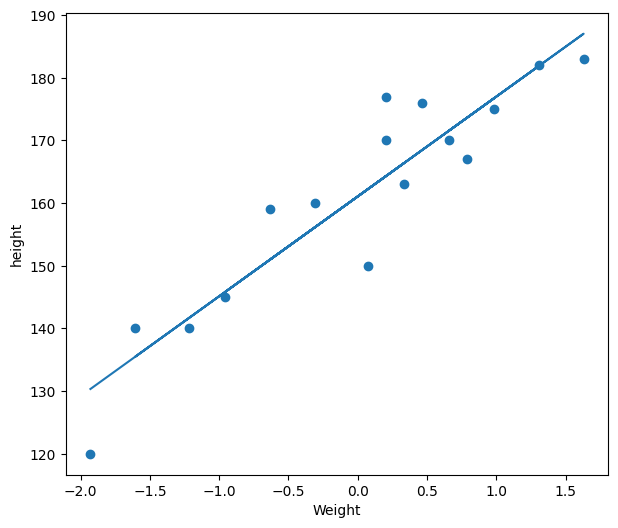

In [54]:
plt.figure(figsize=(7,6))
plt.scatter(X_train,y_train)
plt.plot(X_train, model.predict(X_train))
plt.xlabel("Weight")
plt.ylabel("height")
plt.show()

In [55]:
#display adjusted R-squared
score=r2_score(y_test,y_pred)
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.8188844932459571

In [56]:
## OLS Linear Regression
import statsmodels.api as sm
model_sm=sm.OLS(y_train,X_train).fit()
prediction=model_sm.predict(X_test)
print(prediction)

print(model_sm.summary())

[-17.33040824   3.28569078 -27.63845775  -2.89913892 -30.7308726
  31.11742446  20.80937495]
                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.010
Model:                            OLS   Adj. R-squared (uncentered):             -0.056
Method:                 Least Squares   F-statistic:                             0.1465
Date:                Mon, 11 Nov 2024   Prob (F-statistic):                       0.707
Time:                        14:42:24   Log-Likelihood:                         -104.02
No. Observations:                  16   AIC:                                      210.0
Df Residuals:                      15   BIC:                                      210.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    st

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)


In [57]:
## Prediction For new data
model_sm.predict(scaler.transform([[72]]))


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([-2.89913892])